# Single Image Prediction
In this notebook, we load our fully trained CNN and test it on a single random image from our dataset. This is the exact logic we will use in Phase 2 for the live webcam!


In [13]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import random
import numpy as np

device = torch.device('cpu')

## 1. Rebuild the CNN and Load Weights


In [14]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()
        self.block1 = nn.Sequential(nn.Conv2d(1, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2), nn.Dropout(0.25))
        self.block2 = nn.Sequential(nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(), nn.Conv2d(128, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2), nn.Dropout(0.25))
        self.block3 = nn.Sequential(nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2, 2), nn.Dropout(0.25))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(256 * 6 * 6, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.classifier(self.block3(self.block2(self.block1(x))))

model = EmotionCNN(num_classes=7).to(device)
model.load_state_dict(torch.load('../models/best_emotion_cnn.pth', map_location=device))
model.eval()
print("Model ready for prediction.")

Model ready for prediction.


## 2. Prepare the Image Pipeline
The image must be processed exactly how the CNN expects it: 48x48, Grayscale, and Normalized.


In [15]:
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

## 3. Predict on a Random Image


Testing image from actual class: SAD


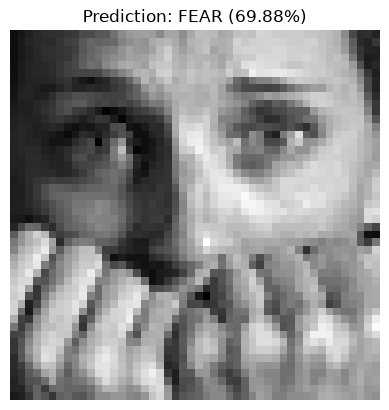


--- Probability Distribution ---
Fear: 69.88%
Sad: 20.52%
Surprise: 4.54%
Neutral: 2.33%
Happy: 1.34%
Angry: 1.07%
Disgust: 0.31%


In [16]:
def predict_image(image_path):
    img = Image.open(image_path)
    input_tensor = preprocess(img)
    input_batch = input_tensor.unsqueeze(0).to(device)  # Add batch dimension
    
    with torch.no_grad():
        output = model(input_batch)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        
    probs_dict = {classes[i]: probabilities[i].item() * 100 for i in range(len(classes))}
    sorted_probs = dict(sorted(probs_dict.items(), key=lambda item: item[1], reverse=True))
    
    predicted_class = list(sorted_probs.keys())[0]
    confidence = list(sorted_probs.values())[0]
    
    # Display results
    plt.imshow(img, cmap='gray')
    plt.title(f"Prediction: {predicted_class.upper()} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()
    
    print("\n--- Probability Distribution ---")
    for emotion, prob in sorted_probs.items():
        print(f"{emotion.capitalize()}: {prob:.2f}%")

# Pick a random image from the test set
test_dir = '../dataset/test'
random_class = random.choice(classes)
class_dir = os.path.join(test_dir, random_class)
random_img = random.choice(os.listdir(class_dir))
image_path = os.path.join(class_dir, random_img)

print(f"Testing image from actual class: {random_class.upper()}")
predict_image(image_path)